In [1]:
#Imports and NLTK Setup
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
#Data Loading & Initial Inspection (Phase 1)
# Load dataset
df = pd.read_csv("Flipkart_Reviews_Sentiment_Analysis_30000x25.csv")

print(f"Dataset Shape: {df.shape}")
print("\nColumns:", df.columns.tolist())
print("\nMissing Values Count:")
print(df.isnull().sum())

# Clean missing review text
df["Review_Text"] = df["Review_Text"].fillna("")
df["Review_Summary"] = df["Review_Summary"].fillna("")

Dataset Shape: (30000, 25)

Columns: ['Review_ID', 'Product_ID', 'Product_Name', 'Category', 'Brand', 'Product_Price', 'Discount_Percentage', 'Selling_Price', 'Rating', 'Review_Summary', 'Review_Text', 'Sentiment', 'Sentiment_Score', 'Customer_City', 'Review_Date', 'Verified_Purchase', 'Helpful_Votes', 'Not_Helpful_Votes', 'Payment_Method', 'Purchase_Channel', 'Delivery_Partner', 'Delivery_Days', 'Customer_Device', 'Review_Confidence', 'Customer_Experience_Score']

Missing Values Count:
Review_ID                      0
Product_ID                     0
Product_Name                   0
Category                       0
Brand                          0
Product_Price                  0
Discount_Percentage            0
Selling_Price                  0
Rating                         0
Review_Summary               240
Review_Text                    0
Sentiment                      0
Sentiment_Score                0
Customer_City                300
Review_Date                    0
Verified_Purc

In [5]:
#Feature Preprocessing & Combination
# Combine Review Summary and Review Text
df["Combined_Review"] = (
    df["Review_Summary"].astype(str) + " " + df["Review_Text"].astype(str)
)

# Text cleaning & Lemmatization function
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def clean_text(text):
    text = text.lower()
    # Retain alphabetic characters
    words = [
        lemmatizer.lemmatize(word)
        for word in text.split()
        if word.isalpha() and word not in stop_words
    ]
    return " ".join(words)


df["Cleaned_Review"] = df["Combined_Review"].apply(clean_text)
print("Sample Cleaned Review:", df["Cleaned_Review"].iloc[0])

Sample Cleaned Review: loved good work keyboard feel


In [6]:
#Train-Test Split with Stratification
X = df["Cleaned_Review"]
y = df["Sentiment"]

# Stratified Split to preserve class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 24000
Test set size: 6000


--- Classification Report ---
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00      1062
     Neutral       1.00      1.00      1.00      1204
    Positive       1.00      1.00      1.00      3734

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



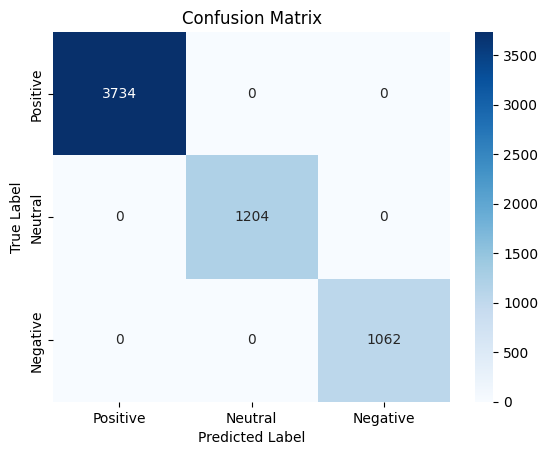

In [7]:
#TF-IDF Vectorization & Model Training (Handling Class Bias)
# TF-IDF Vectorizer (Unigrams & Bigrams)
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = tfidf.fit_transform(X_train)
X_test_vec = tfidf.transform(X_test)

# Train Logistic Regression with Balanced Class Weights to eliminate positive class bias
model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
model.fit(X_train_vec, y_train)

# Model Evaluation
y_pred = model.predict(X_test_vec)
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=["Positive", "Neutral", "Negative"])
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Positive", "Neutral", "Negative"],
    yticklabels=["Positive", "Neutral", "Negative"],
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [8]:
#Export Saved Pickles
# Save trained artifacts
joblib.dump(model, "sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")
print("Successfully exported sentiment_model.pkl and tfidf_vectorizer.pkl!")

Successfully exported sentiment_model.pkl and tfidf_vectorizer.pkl!
